# Assignment 2 - Hugging Face transformers for FactNews

This notebook builds and evaluates **traditional machine learning** classifiers for the **FactNews** dataset, a Brazilian Portuguese sentence-level dataset for factuality and media-bias analysis.

This project was developed by Elton Tamele (up201908676@up.pt), Maureen Ah-shú (up201708043@up.pt), and Tomás Teixeira (up202208041@up.pt) for the Natural Language Processing course in MEIC, FEUP.

## Goals
..

## Classification tasks
This notebook works with the two formulations exposed by the **FactNews** repository:

- **Task A** - 3-class sentence classification
  - Labels: biased, factual, quote
- **Task B** - binary factuality design classification  
  - Labels: factual, non_factual

## Dataset provenance

According to the **FactNews** repository and the accompanying RANLP 2023 paper, the dataset:
- is in **Brazilian Portuguese**
- contains **6,191 annotated sentences**
- comes from **300 news documents** covering **100 news stories**
- uses three media outlets: **Folha de São Paulo**, **Estadão**, and **O Globo**
- covers domains such as **politics, world, sports, daily, culture, and science**
- includes sentence-level annotations for:
  - **factual spans** as 0
  - **biased spans** as 1
  - **quotes** as -1

The original paper reports the following strong baselines:
- **Sentence-level factuality prediction**: **F1 = 0.88** with fine-tuned BERT
- **Sentence-level media bias prediction**: **F1 = 0.67** with fine-tuned BERT

Since this assignment forbids deep learning architectures such as Transformers, those values are used **only as contextual reference**, not as target models.

### References
- Repository: [franciellevargas/FactNews](https://github.com/franciellevargas/FactNews)
- Paper: *Predicting Sentence-Level Factuality of News and Bias of Media Outlets* (RANLP 2023)

## Environment Preparation

In [ ]:
# !pip install -U torch torchvision torchaudio
# !pip install -U datasets transformers accelerate

In [1]:
!pip install -q \
    "datasets>=3.0.0" \
    "transformers>=4.44.0" \
    "accelerate>=0.34.0" \
    pandas numpy matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn

!pip install --upgrade torchao

In [2]:
import sys
mods_to_remove = [k for k in sys.modules if "torchvision" in k]
for mod in mods_to_remove:
    del sys.modules[mod]

# If needed, uncomment the next line to install dependencies.
%pip install pandas==2.2.2 numpy==2.0.2 matplotlib scikit-learn nltk gensim wordcloud imbalanced-learn -q
!pip install transformers datasets accelerate -q

import re
import warnings
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (classification_report,accuracy_score,f1_score,confusion_matrix)
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling

from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch
import torch.nn as nn
import gc

from peft import LoraConfig, get_peft_model, TaskType


import pickle
from google.colab import drive
drive.mount('/content/drive')



SAVE_DIR = "/content/drive/MyDrive/pln_results/"
import os; os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

In [3]:
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_dataset_factuality_design.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/factnews_augmented_instances_cloude.csv"
!wget -q "https://raw.githubusercontent.com/tomast100/PLN_Project_Data/master/historico_de_materias.csv"

df_main = pd.read_csv("factnews_dataset.csv")
df_fact = pd.read_csv("factnews_dataset_factuality_design.csv")
df_augmented = pd.read_csv("factnews_augmented_instances_cloude.csv")
df_domain_adap = pd.read_csv("historico_de_materias.csv")

print("Main dataset shape:", df_main.shape)
print("Factuality-design dataset shape:", df_fact.shape)
print("Fact News augmented dataset shape:", df_fact.shape)

Main dataset shape: (6191, 7)
Factuality-design dataset shape: (6191, 7)
Fact News augmented dataset shape: (6191, 7)


### Column description

From inspection, both files have the same schema:

- `file`: original document identifier
- `id_sente`: sentence identifier
- `id_article`: article/story identifier
- `domain`: news domain
- `year`: publication year
- `sentences`: sentence text
- `classe`: label

The difference is in the meaning of `classe`:
- in the **main dataset** it encodes the 3-way annotation
- in the **factuality design dataset** it encodes the binary factuality design

## Exploratory Data Analysis

In [4]:
# Install dependencies as needed:
# !pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the EXACT path to the file you want to load from the dataset
# For the marlesson/news-of-the-site-folhauol dataset, the main file is 'articles.csv'
file_path = "articles.csv"

# Load the latest version using the updated 'dataset_load' method
df_domain_adap_two = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "marlesson/news-of-the-site-folhauol",
    file_path,
)

print("First 5 records:")
print(df_domain_adap_two.head())

Using Colab cache for faster access to the 'news-of-the-site-folhauol' dataset.
First 5 records:
                                               title  \
0  Lula diz que está 'lascado', mas que ainda tem...   
1  'Decidi ser escrava das mulheres que sofrem', ...   
2  Três reportagens da Folha ganham Prêmio Petrob...   
3  Filme 'Star Wars: Os Últimos Jedi' ganha trail...   
4  CBSS inicia acordos com fintechs e quer 30% do...   

                                                text        date   category  \
0  Com a possibilidade de uma condenação impedir ...  2017-09-10      poder   
1  Para Oumou Sangaré, cantora e ativista malines...  2017-09-10  ilustrada   
2  Três reportagens da Folha foram vencedoras do ...  2017-09-10      poder   
3  A Disney divulgou na noite desta segunda-feira...  2017-09-10  ilustrada   
4  O CBSS, banco da holding Elopar dos sócios Bra...  2017-09-10    mercado   

  subcategory                                               link  
0         NaN  http://ww

In [5]:
df_augmented.columns = df_augmented.columns.str.strip()

label_map = {-1: "quote", 0: "factual", 1: "biased"}
id2label  = {0: "biased", 1: "factual", 2: "quote"}
label2id  = {"biased": 0, "factual": 1, "quote": 2}

df_main["label"] = df_main["classe"].map(label_map)
df_main["label_id"] = df_main["label"].map(label2id)

print("Task A - Main label distribution:")
display(df_main["label"].value_counts().rename_axis("label").reset_index(name="count"))

print(df_domain_adap.head())

Task A - Main label distribution:


,label,count
0,factual,4242
1,quote,1391
2,biased,558


         data                                        url_noticia  \
0  2014-01-25  https://web.archive.org/web/20140125123631/htt...   
1  2014-01-25  https://web.archive.org/web/20140125123631/htt...   
2  2014-01-25  https://web.archive.org/web/20140125123631/htt...   
3  2014-01-25  https://web.archive.org/web/20140125123631/htt...   
4  2014-01-25  https://web.archive.org/web/20140125123631/htt...   

                                   url_noticia_curto  \
0  http://g1.globo.com/economia/noticia/2014/01/m...   
1  http://g1.globo.com/economia/noticia/2014/01/p...   
2  http://g1.globo.com/economia/noticia/2014/01/t...   
3  http://g1.globo.com/economia/noticia/2014/01/g...   
4  http://g1.globo.com/economia/noticia/2014/01/p...   

                                              titulo  \
0  Mesmo com alta do dólar, gastos de brasileiros...   
1  Para Dilma, é 'apressada' a tese de que emerge...   
2  Temos sido capazes de reduzir a inflação', diz...   
3  Governo argentino autoriza 

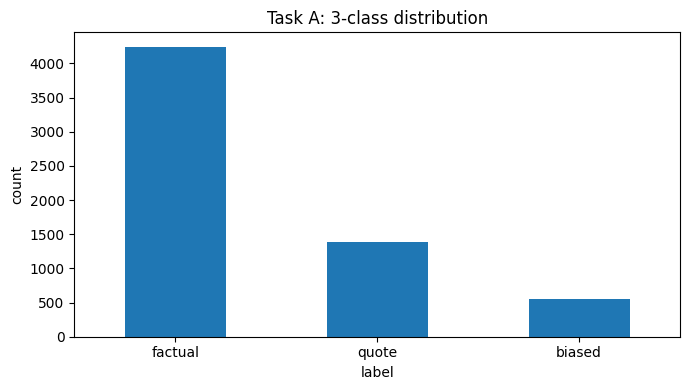

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

df_main["label"].value_counts().plot(kind="bar", ax=ax, title="Task A: 3-class distribution")
ax.set_xlabel("label")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=0)



plt.tight_layout()
plt.show()

### Observation

The dataset is **imbalanced**:
- `factual` is clearly the majority class
- `quote` is the smallest class in Task A
- the binary task is still imbalanced

In [7]:
display(df_main["domain"].value_counts().rename_axis("domain").reset_index(name="count"))

,domain,count
0,politics,3873
1,world,880
2,sports,490
3,daily,413
4,culture,412
5,science,123


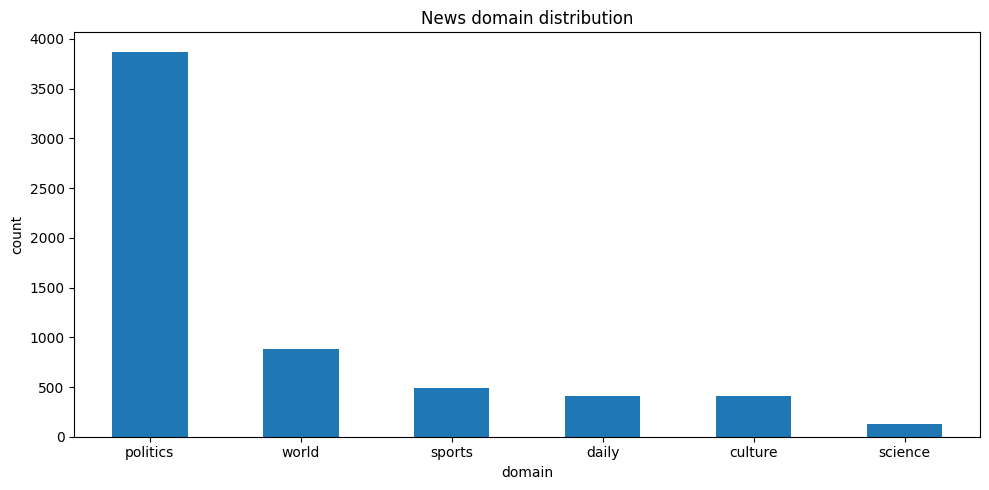

In [8]:
df_main["domain"].value_counts().plot(kind="bar", title="News domain distribution")
plt.xlabel("domain")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

`politics` dominates the corpus.  
This is important because it is specifically in political reporting that signs of bias, framing, and citation practices tend to be most common.

In [9]:
stop_words_pt = stopwords.words("portuguese")

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = text.replace("“", '"').replace("”", '"').replace("‘", "'").replace("’", "'")
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\sÀ-ÿ\"']", " ", text)
    text = re.sub(r"_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for frame in (df_main, df_fact):
    frame["text_clean"] = frame["sentences"].apply(clean_text)

def top_tfidf_terms_by_class(df, text_col="sentences", label_col="label", top_n=15):
    texts = df[text_col].fillna("").apply(clean_text)

    vectorizer = TfidfVectorizer(
        min_df=5,
        max_df=0.7,
        ngram_range=(1, 2),
        stop_words=stop_words_pt,
        sublinear_tf=True
    )

    X = vectorizer.fit_transform(texts)
    vocab = np.array(vectorizer.get_feature_names_out())

    results = {}
    for label in sorted(df[label_col].unique()):
        idx = (df[label_col] == label).to_numpy()

        class_mean = np.asarray(X[idx].mean(axis=0)).ravel()
        other_mean = np.asarray(X[~idx].mean(axis=0)).ravel()
        score = class_mean - other_mean

        top_idx = score.argsort()[::-1][:top_n]

        results[label] = pd.DataFrame({
            "term": vocab[top_idx],
            "class_tfidf": class_mean[top_idx],
            "other_tfidf": other_mean[top_idx],
            "distinctive_score": score[top_idx]
        })

    return results

top_terms = top_tfidf_terms_by_class(df_main, top_n=10)

for label, table in top_terms.items():
    print(f"Top terms for class: {label}")
    display(table)

Top terms for class: biased


,term,class_tfidf,other_tfidf,distinctive_score
0,moro,0.010102,0.002076,0.008027
1,kaká,0.008033,0.000215,0.007818
2,discurso,0.008283,0.001576,0.006707
3,campanha,0.009895,0.003370,0.006525
4,torcida,0.006435,0.000370,0.006065
5,seleção,0.007006,0.001013,0.005994
6,bolsonaro,0.016705,0.010886,0.005819
7,minutos,0.006723,0.001021,0.005702
8,equador,0.006109,0.000454,0.005654
9,maracanã,0.006032,0.000403,0.005629


Top terms for class: factual


,term,class_tfidf,other_tfidf,distinctive_score
0,segundo,0.012686,0.004821,0.007865
1,feira,0.010013,0.002837,0.007176
2,mil,0.007261,0.001222,0.006039
3,ano,0.008726,0.002957,0.005769
4,nesta,0.007795,0.002466,0.005329
5,votos,0.006205,0.001718,0.004487
6,pesquisa,0.005839,0.001893,0.003946
7,terça,0.004617,0.000714,0.003903
8,bilhões,0.004208,0.000425,0.003783
9,após,0.006856,0.003136,0.003720


Top terms for class: quote


,term,class_tfidf,other_tfidf,distinctive_score
0,disse,0.027730,0.005862,0.021868
1,afirmou,0.018099,0.003777,0.014323
2,gente,0.010128,0.000000,0.010128
3,porque,0.010319,0.001504,0.008815
4,vida,0.009441,0.000985,0.008456
5,sempre,0.008862,0.000796,0.008066
6,tudo,0.008093,0.000307,0.007786
7,agora,0.010578,0.003108,0.007470
8,vamos,0.007214,0.000050,0.007164
9,todos,0.008947,0.002428,0.006519


### Observation

The TF-IDF tables above are not a full linguistic analysis, but they are useful for spotting:
- Subjective and persuasive language in the biased class
    - Frequent terms such as “gente”, “vamos”, “sempre”, and “todos” suggest generalizations, inclusivity strategies, and rhetorical framing typical of opinionated discourse.
- Structured, evidence-based language in the factual class
    - Terms like “segundo”, “pesquisa”, “votos”, “bilhões”, and “mil” point to data-driven reporting, with references to sources, statistics, and measurable quantities.
- Entity-heavy and context-specific vocabulary in the quote class
    - Named entities like “moro”, “kaká”, and “bolsonaro”, along with terms such as “discurso”, “campanha”, and “maracanã”, suggest that this class is strongly tied to specific people, events, and domains (e.g., politics and sports).

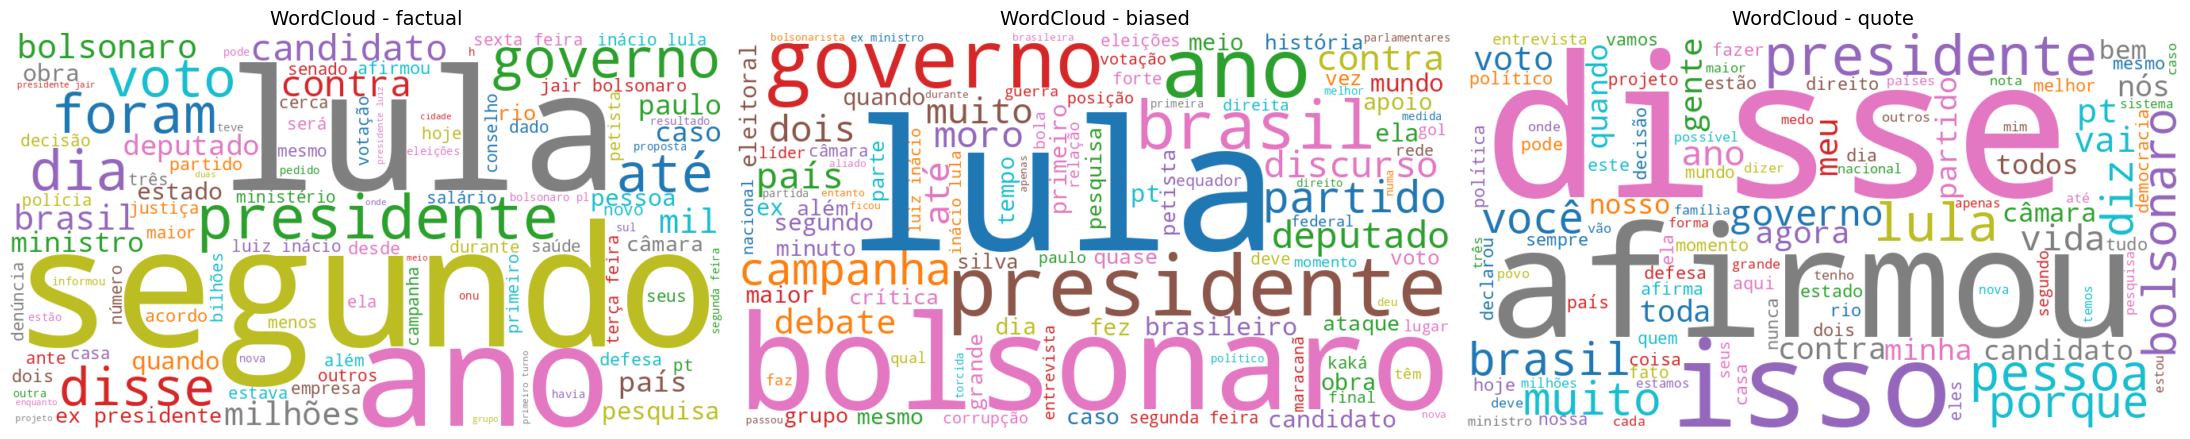

In [10]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

stopwords_pt = set(STOPWORDS)
stopwords_pt.update([
    "a", "o", "os", "as", "de", "do", "da", "dos", "das",
    "e", "é", "em", "um", "uma", "uns", "umas",
    "para", "por", "com", "sem", "no", "na", "nos", "nas",
    "ao", "aos", "à", "às", "que", "se", "como", "mais",
    "mas", "ou", "foi", "ser", "tem", "há", "já", "outro",
    "pelo", "pela", "após", "está", "ainda", "seu", "sua",
    "ter", "eu", "ele", "ela" "isso", "não", "esse", "essa",
    "são", "sobre", "nem", "qualquer", "todo", "era", "também",
    "entre", "depois"
])


labels = ["factual", "biased", "quote"]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, label in zip(axes, labels):
    text = " ".join(
        df_main.loc[df_main["label"] == label, "text_clean"]
        .dropna()
        .astype(str)
        .tolist()
    )

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        stopwords=stopwords_pt,
        max_words=100,
        colormap="tab10"
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"WordCloud - {label}", fontsize=14)

plt.tight_layout()
plt.show()

### Observation

The word clouds reinforce the earlier TF-IDF analysis:

- **factual** sentences concentrate around more neutral and informational vocabulary, often linked to reporting, events, institutions, and quantified facts.
- **biased** sentences tend to include more evaluative or rhetorical wording, which is compatible with framing.
- **quote** sentences show strong concentration of named entities and speech-related vocabulary, which makes sense because this class is closely tied to reported speech.

Word clouds are only exploratory and is not meant to be treated as rigorous evidence on their own, but they are useful to quickly visualize lexical tendencies across classes.

## Data Preparation

In [11]:
train_df, test_df = train_test_split(
    df_main, test_size=0.2, random_state=42, stratify=df_main["label_id"]
)

hf_label_map = {'biased': 0, 'factual': 1, 'quote': 2}
df_augmented['label_id'] = df_augmented['label'].map(hf_label_map)

df_augmented = df_augmented[['sentences', 'label_id']]


# Training Arguments

training_args = TrainingArguments(
    output_dir="./mbert_factnews",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
    seed=42,
    logging_steps=50,
    report_to="none"
)

## Free memory function

In [12]:
TARGET_NAMES = ["biased", "factual", "quote"]

def free_memory(*models):
    for m in models:
        del m
    gc.collect()
    torch.cuda.empty_cache()
    print(f"VRAM free: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")


def save_results(name, y_true, y_pred):
    data = {"y_true": y_true, "y_pred": y_pred}
    with open(f"{SAVE_DIR}{name.replace(' ', '_')}.pkl", "wb") as f:
        pickle.dump(data, f)
    print(f"Saved: {name}")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

## Hugging Face Transformers

[Hugging Face](https://huggingface.co) is an open-source platform that provides
a central hub for sharing pre-trained machine learning models and datasets.
Its core library, `transformers`, offers a unified API to load, fine-tune, and
evaluate thousands of pre-trained models for Natural Language Processing tasks.

To select appropriate models for this task, we searched the Hugging Face Hub
for models compatible with Brazilian Portuguese and suitable for sequence
classification. This led us to the following two models, which will be
evaluated and compared throughout this notebook:

- **mBERT** (`google-bert/bert-base-multilingual-cased`): a multilingual BERT
  model pre-trained on Wikipedia across 104 languages, including Portuguese.
- **BERTimbau** (`neuralmind/bert-base-portuguese-cased`): a BERT model
  pre-trained exclusively on Brazilian Portuguese data (BrWaC corpus).

Each model is explored in detail in the sections below.

**Imbalaced**

Como um dos nossos principais problemas na última entrega foi conseguir mitigar os problemas que o desblanceamento do dataset nos causou, decidimos testar mais técnicas para lidar com este problema. Essas técnicas testadas foram as seguintes:

- Without resampling: Já presente na última entrega
- Manual Oversampling: Já presente na última entrega
- Class weight in loss: Já presente na última entrega
-

### mBert


**mBERT** (`google-bert/bert-base-multilingual-cased`) is a multilingual
version of BERT (Bidirectional Encoder Representations from Transformers),
introduced by Devlin et al. (2019). It was pre-trained on Wikipedia text
from 104 languages simultaneously, including Portuguese, using Masked
Language Modelling (MLM) and Next Sentence Prediction (NSP).

Despite not being specifically designed for Portuguese, mBERT serves as a
strong multilingual baseline for NLP tasks across many languages. It contains
**179M parameters** and uses a cased WordPiece tokenizer shared across all
104 languages.

In [13]:
results = {}

MODEL_NAME = "google-bert/bert-base-multilingual-cased"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )


train_ds = Dataset.from_pandas(train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))
test_ds  = Dataset.from_pandas(test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

### Without resampling

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.352123,0.332112,0.698395,0.852642
2,0.254437,0.324311,0.775674,0.885585
3,0.174331,0.391141,0.798154,0.893546


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=930, training_loss=0.29795973172751805, metrics={'train_runtime': 309.3287, 'train_samples_per_second': 48.027, 'train_steps_per_second': 3.007, 'total_flos': 977203233441792.0, 'train_loss': 0.29795973172751805, 'epoch': 3.0})

In [ ]:
TARGET_NAMES = ["biased", "factual", "quote"]

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Base", y_true, y_pred)


free_memory(model)

              precision    recall  f1-score   support

      biased       0.61      0.50      0.55       112
     factual       0.92      0.95      0.93       849
       quote       0.92      0.90      0.91       278

    accuracy                           0.90      1239
   macro avg       0.82      0.78      0.80      1239
weighted avg       0.89      0.90      0.89      1239

Saved: mBERT - Base
VRAM free: 12.66 GB


#### Manual Oversampling

In [ ]:
train_biased  = train_df[train_df["label_id"] == 0]
train_factual = train_df[train_df["label_id"] == 1]
train_quote   = train_df[train_df["label_id"] == 2]

train_biased_up = resample(train_biased, replace=True,
                           n_samples=len(train_factual), random_state=42)
train_quote_up  = resample(train_quote,  replace=True,
                           n_samples=len(train_factual), random_state=42)

train_balanced = pd.concat([train_factual, train_biased_up, train_quote_up])
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)



train_ds_os = Dataset.from_pandas(
    train_balanced[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_os = train_ds_os.map(tokenize, batched=True)
train_ds_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])



model_os = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_os = Trainer(
    model=model_os,
    args=training_args,
    train_dataset=train_ds_os,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 2: Oversampling ===")
trainer_os.train()


preds_os = trainer_os.predict(test_ds)
y_pred_os = np.argmax(preds_os.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_os,
      target_names=["biased", "factual", "quote"]))


preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))


save_results("mBERT - Oversampling", y_true, y_pred)


free_memory(model_os)

#### Class weights in loss

In [ ]:
weights = compute_class_weight("balanced",
                               classes=np.array([0, 1, 2]),
                               y=train_df["label_id"].values)
class_weights = torch.tensor(weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(
            weight=class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

model_cw = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

trainer_cw = WeightedTrainer(
    model=model_cw,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

print("=== Variation 3: Class Weights ===")
trainer_cw.train()

preds_cw = trainer_cw.predict(test_ds)
y_pred_cw = np.argmax(preds_cw.predictions, axis=-1)
print(classification_report(test_df["label_id"].values, y_pred_cw,
      target_names=["biased", "factual", "quote"]))



preds_output = trainer.predict(test_ds)
y_true = test_df["label_id"].values


print(classification_report(y_true, y_pred_cw, target_names=TARGET_NAMES))


save_results("mBERT - Class weight in loss", y_true, y_pred_cw)


free_memory(model_cw)

####  Synthetic Data Augmentation

In [ ]:
# 1. Calculate how many instances are needed to match the majority real class
real_counts = train_df['label_id'].value_counts()
target_size = real_counts.max()

# 2. Mix real data with the exact missing amount of synthetic data
mixed_dfs = [train_df[['sentences', 'label_id']]]

for class_id, current_size in real_counts.items():
    missing_amount = target_size - current_size

    if missing_amount > 0:
        # Get synthetic data for this specific class
        class_synthetic_data = df_augmented[df_augmented['label_id'] == class_id]

        # Sample exactly the missing amount (replace=True handles cases where we need more than available)
        sampled_synthetic = class_synthetic_data.sample(n=missing_amount, replace=(len(class_synthetic_data) < missing_amount), random_state=42)
        mixed_dfs.append(sampled_synthetic)

# 3. Concatenate and Shuffle
train_balanced_ai = pd.concat(mixed_dfs, ignore_index=True)
train_balanced_ai = train_balanced_ai.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribution after Intelligent Data Augmentation (Train Set):")
print(train_balanced_ai['label_id'].value_counts())

# 4. Create Hugging Face Dataset
train_ds_ai = Dataset.from_pandas(train_balanced_ai.rename(columns={"label_id": "labels"}))
train_ds_ai = train_ds_ai.map(tokenize, batched=True)
train_ds_ai.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# 5. Load Clean Model
model_ai = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 6. Initialize Trainer
trainer_ai = Trainer(
    model=model_ai,
    args=training_args,
    train_dataset=train_ds_ai,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

# 7. Train and Evaluate
trainer_ai.train()

preds_ai = trainer_ai.predict(test_ds)
y_pred_ai = np.argmax(preds_ai.predictions, axis=-1)
y_true = test_df["label_id"].values

print("\n=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred_ai,
    target_names=["biased", "factual", "quote"]
))

save_results("mBERT - Synthetic Augmentation (Gemini)", y_true, y_pred_ai)
free_memory(model_ai)

Distribution after Intelligent Data Augmentation (Train Set):
label_id
0    3393
1    3393
2    3393
Name: count, dtype: int64


Map:   0%|          | 0/10179 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.212072,0.375189,0.720833,0.863429
2,0.151538,0.451709,0.770235,0.874697
3,0.047938,0.458360,0.788949,0.884740


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


=== Classification Report ===
              precision    recall  f1-score   support

      biased       0.62      0.48      0.54       112
     factual       0.91      0.94      0.93       849
       quote       0.90      0.90      0.90       278

    accuracy                           0.89      1239
   macro avg       0.81      0.77      0.79      1239
weighted avg       0.88      0.89      0.88      1239

Saved: mBERT - Synthetic Augmentation (Gemini)
VRAM free: 11.53 GB


### BERTimbau

**BERTimbau** (`neuralmind/bert-base-portuguese-cased`) is a Portuguese-specific
version of BERT (Bidirectional Encoder Representations from Transformers),
introduced by Souza et al. (2020). It was pre-trained exclusively on a large-scale
Portuguese web corpus (brWaC - Brazilian Web as Corpus), using Masked Language
Modelling (MLM) and Next Sentence Prediction (NSP).

Because it is specifically designed for Portuguese, BERTimbau captures the language's
nuances better than multilingual models, serving as a strong monolingual baseline
for Portuguese NLP tasks. It contains **110M parameters** and uses a cased WordPiece
tokenizer tailored to the Portuguese vocabulary.

#### BERTimbau: Tokenization and Dataset Formatting

Before training any BERTimbau model, the raw text must be converted into numerical representations that the Transformer architecture can process.

In this foundational block, we initialize the official **BERTimbau Cased Tokenizer** (`neuralmind/bert-base-portuguese-cased`). We retain the case sensitivity (`do_lower_case=False`), as uppercase letters often carry important semantic cues in journalistic texts (e.g., proper nouns, acronyms, or sensationalist capitalization).

The raw `sentences` from our training and testing dataframes are mapped into a structured Hugging Face `Dataset`. Each sentence is truncated or padded to a uniform length of 128 tokens. Finally, the dataset is converted into **PyTorch tensors** (`input_ids` and `attention_mask`), making it universally ready for the upcoming classification and fine-tuning stages.

In [14]:
BERTIMBAU_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer_bi = AutoTokenizer.from_pretrained(
    BERTIMBAU_NAME,
    do_lower_case=False
)

def tokenize_bi(batch):
    return tokenizer_bi(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_ds_bi = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_bi = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_bi = train_ds_bi.map(tokenize_bi, batched=True)
test_ds_bi  = test_ds_bi.map(tokenize_bi,  batched=True)

train_ds_bi.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bi.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

#### Without Sampling

In [ ]:
# ── BERTimbau ────────────────────────────────────────────────────────────────
model_bi = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi = Trainer(
    model=model_bi,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

trainer_bi.train()

preds_bi = trainer_bi.predict(test_ds_bi)
y_pred_bi = np.argmax(preds_bi.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi,
    target_names=["biased", "factual", "quote"]
))

print(classification_report(y_true, y_pred_bi, target_names=TARGET_NAMES))


save_results("BERTimbau - Base", y_true, y_pred_bi)


free_memory(model_bi)

#### Manual Oversampling

In [ ]:
# ── BERTimbau: Oversampling Manual ───────────────────────────────────────────
train_biased_bi  = train_df[train_df["label_id"] == 0]
train_factual_bi = train_df[train_df["label_id"] == 1]
train_quote_bi   = train_df[train_df["label_id"] == 2]

train_biased_up_bi = resample(train_biased_bi, replace=True,
                               n_samples=len(train_factual_bi), random_state=42)
train_quote_up_bi  = resample(train_quote_bi,  replace=True,
                               n_samples=len(train_factual_bi), random_state=42)

train_balanced_bi = pd.concat([train_factual_bi, train_biased_up_bi, train_quote_up_bi])
train_balanced_bi = train_balanced_bi.sample(frac=1, random_state=42).reset_index(drop=True)

# Tokenizar o dataset balanceado
train_ds_bi_os = Dataset.from_pandas(
    train_balanced_bi[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
train_ds_bi_os = train_ds_bi_os.map(tokenize_bi, batched=True)
train_ds_bi_os.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Modelo limpo
model_bi_os = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

trainer_bi_os = Trainer(
    model=model_bi_os,
    args=training_args,
    train_dataset=train_ds_bi_os,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Oversampling ===")
trainer_bi_os.train()

preds_bi_os = trainer_bi_os.predict(test_ds_bi)
y_pred_bi_os = np.argmax(preds_bi_os.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_os,
    target_names=["biased", "factual", "quote"]
))


save_results("BERTimbau - Oversampling", y_true, y_pred_bi_os)


free_memory(model_bi_os)

#### Class Weight in loss

In [ ]:

model_bi_cw = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


trainer_bi_cw = WeightedTrainer(
    model=model_bi_cw,
    args=training_args,
    train_dataset=train_ds_bi,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

print("=== BERTimbau: Class Weights ===")
trainer_bi_cw.train()

preds_bi_cw = trainer_bi_cw.predict(test_ds_bi)
y_pred_bi_cw = np.argmax(preds_bi_cw.predictions, axis=-1)
print(classification_report(
    test_df["label_id"].values, y_pred_bi_cw,
    target_names=["biased", "factual", "quote"]
))

save_results("BERTimbau - Class Weight", y_true, y_pred_bi_cw)


free_memory(model_bi_cw)

#### Syntetic Data Augmentation

In [24]:
train_ds_bi = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_bi = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_bi = train_ds_bi.map(tokenize_bi, batched=True)
test_ds_bi  = test_ds_bi.map(tokenize_bi,  batched=True)

train_ds_bi.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_bi.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

# 1. Calculate how many instances are needed to match the majority real class
real_counts = train_df['label_id'].value_counts()
target_size = real_counts.max()

# 2. Mix real data with the exact missing amount of synthetic data
mixed_dfs_bi = [train_df[['sentences', 'label_id']]]

for class_id, current_size in real_counts.items():
    missing_amount = target_size - current_size

    if missing_amount > 0:
        # Get synthetic data for this specific class
        class_synthetic_data = df_augmented[df_augmented['label_id'] == class_id]

        # Sample exactly the missing amount (replace=True handles cases where we need more than available)
        sampled_synthetic = class_synthetic_data.sample(n=missing_amount, replace=(len(class_synthetic_data) < missing_amount), random_state=42)
        mixed_dfs_bi.append(sampled_synthetic)

# 3. Concatenate and Shuffle
train_balanced_bi_ai = pd.concat(mixed_dfs_bi, ignore_index=True)
train_balanced_bi_ai = train_balanced_bi_ai.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribution after Intelligent Data Augmentation (Train Set - BERTimbau):")
print(train_balanced_bi_ai['label_id'].value_counts())

# 4. Create Hugging Face Dataset & Tokenize (Using tokenize_bi)
train_ds_bi_ai = Dataset.from_pandas(train_balanced_bi_ai.rename(columns={"label_id": "labels"}))
train_ds_bi_ai = train_ds_bi_ai.map(tokenize_bi, batched=True)
train_ds_bi_ai.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# 5. Load Clean BERTimbau Model
model_bi_ai = AutoModelForSequenceClassification.from_pretrained(
    BERTIMBAU_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 6. Initialize Trainer (Make sure to use test_ds_bi)
trainer_bi_ai = Trainer(
    model=model_bi_ai,
    args=training_args,
    train_dataset=train_ds_bi_ai,
    eval_dataset=test_ds_bi,
    compute_metrics=compute_metrics,
)

# 7. Train and Evaluate
print("\n=== Training Started (BERTimbau - Synthetic Augmentation) ===")
trainer_bi_ai.train()

preds_bi_ai = trainer_bi_ai.predict(test_ds_bi)
y_pred_bi_ai = np.argmax(preds_bi_ai.predictions, axis=-1)
y_true = test_df["label_id"].values

print("\n=== Classification Report (BERTimbau) ===")
print(classification_report(
    y_true,
    y_pred_bi_ai,
    target_names=["biased", "factual", "quote"]
))

save_results("BERTimbau - Synthetic Augmentation (Gemini)", y_true, y_pred_bi_ai)
free_memory(model_bi_ai)

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

Distribution after Intelligent Data Augmentation (Train Set - BERTimbau):
label_id
0    3393
1    3393
2    3393
Name: count, dtype: int64


Map:   0%|          | 0/10179 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== Classification Report (BERTimbau) ===
              precision    recall  f1-score   support

      biased       0.64      0.54      0.58       112
     factual       0.93      0.95      0.94       849
       quote       0.95      0.94      0.94       278

    accuracy                           0.91      1239
   macro avg       0.84      0.81      0.82      1239
weighted avg       0.91      0.91      0.91      1239

Saved: BERTimbau - Synthetic Augmentation (Gemini)
VRAM free: 13.49 GB


#### Domain Adaptation

In [15]:
import pandas as pd
from datasets import Dataset

print("=== Bonus: Domain Adaptation (MLM) ===")

# 1. Clean the FIRST extra dataset (df_domain_adap)
df_domain_adap['conteudo_noticia'] = df_domain_adap['conteudo_noticia'].astype(str)
df_domain_adap['conteudo_noticia'] = df_domain_adap['conteudo_noticia'].str.replace(r'[\n\t]', ' ', regex=True)
df_domain_adap['conteudo_noticia'] = df_domain_adap['conteudo_noticia'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Sample and rename column to match 'sentences'
df_domain_adap_sample = df_domain_adap.sample(frac=1, random_state=42)[['conteudo_noticia']]
df_domain_adap_sample = df_domain_adap_sample.rename(columns={'conteudo_noticia': 'sentences'})

# 2. Clean the SECOND extra dataset (df_domain_adap_two)
# The text is in the 'text' column, so we clean it exactly the same way
df_domain_adap_two['text'] = df_domain_adap_two['text'].astype(str)
df_domain_adap_two['text'] = df_domain_adap_two['text'].str.replace(r'[\n\t]', ' ', regex=True)
df_domain_adap_two['text'] = df_domain_adap_two['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Sample and rename column to match 'sentences'
# Note: You can change frac=1 to frac=0.5 if the dataset is too huge and memory crashes
df_domain_adap_two_sample = df_domain_adap_two.sample(frac=1, random_state=42)[['text']]
df_domain_adap_two_sample = df_domain_adap_two_sample.rename(columns={'text': 'sentences'})

# 3. Concatenate EVERYTHING
textos_factnews = pd.concat([train_df[['sentences']], test_df[['sentences']]], ignore_index=True)

all_real_texts = pd.concat([
    textos_factnews,
    df_domain_adap_sample,
    df_domain_adap_two_sample # <-- Added the new dataset here
], ignore_index=True)

# Shuffle all texts
all_real_texts = all_real_texts.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total sentences for MLM training: {len(all_real_texts)}")

# 4. Create Hugging Face Dataset and Tokenize
mlm_dataset = Dataset.from_pandas(all_real_texts)

def tokenize_for_mlm(batch):
    return tokenizer_bi(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

print("Tokenizing texts for Masked Language Modeling...")
mlm_dataset = mlm_dataset.map(tokenize_for_mlm, batched=True)
mlm_dataset = mlm_dataset.remove_columns(["sentences"])

# 5. Prepare Collator and Model
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer_bi,
    mlm=True,
    mlm_probability=0.15
)

model_mlm = AutoModelForMaskedLM.from_pretrained(BERTIMBAU_NAME)

mlm_training_args = TrainingArguments(
    output_dir="./bertimbau_mlm_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    save_strategy="no",
    fp16=True,
    seed=42,
    logging_steps=500,
    report_to="none"
)

trainer_mlm = Trainer(
    model=model_mlm,
    args=mlm_training_args,
    train_dataset=mlm_dataset,
    data_collator=data_collator,
)

# 6. Train and Save
print("\nStarting Domain Adaptation Training... This might take a while!")
trainer_mlm.train()

ADAPTED_MODEL_PATH = "./bertimbau_domain_adapted"
trainer_mlm.save_model(ADAPTED_MODEL_PATH)
tokenizer_bi.save_pretrained(ADAPTED_MODEL_PATH)

print(f"\nDomain-Adapted model saved successfully to: {ADAPTED_MODEL_PATH}")

import gc
import torch
del model_mlm, trainer_mlm
gc.collect()
torch.cuda.empty_cache()

=== Bonus: Domain Adaptation (MLM) ===
Total sentences for MLM training: 183353
Tokenizing texts for Masked Language Modeling...


Map:   0%|          | 0/183353 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Starting Domain Adaptation Training... This might take a while!


Step,Training Loss
500,1.320313
1000,1.300407
1500,1.296126
2000,1.283372
2500,1.284431
3000,1.279229
3500,1.276787
4000,1.279361
4500,1.257750
5000,1.268025


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Domain-Adapted model saved successfully to: ./bertimbau_domain_adapted


#### LoRA

#### LoRA

**BERTimbau with LoRA + Class Weights in Loss**

This section trains a BERTimbau-based classifier using two complementary
techniques: **LoRA** (Low-Rank Adaptation) for parameter-efficient fine-tuning,
and **class-weighted loss** to mitigate the class imbalance present in FactNews.

**Parameter-Efficient Fine-Tuning with LoRA**

Standard fine-tuning updates **all** parameters of the model, which is
computationally expensive and prone to overfitting on smaller datasets.
**LoRA** (Hu et al., 2022) addresses this by injecting small trainable
**low-rank decomposition matrices** into selected layers of the Transformer,
while keeping the original pre-trained weights **frozen**.

In this experiment, LoRA is applied to the **query, key, and value**
projection matrices of each attention head, with the following configuration:

| Hyperparameter | Value | Description |
|---|---|---|
| `r` | 16 | Rank of the decomposition matrices |
| `lora_alpha` | 32 | Scaling factor for LoRA updates |
| `lora_dropout` | 0.1 | Dropout applied to LoRA layers |
| `target_modules` | query, key, value | Attention projections to adapt |

This means only a **small fraction of the total parameters** are updated
during training, significantly reducing memory usage and training time
while preserving the general language knowledge of BERTimbau.

**Class-Weighted Loss**

As observed throughout this notebook, the FactNews dataset is heavily
skewed towards the `factual` class. To counteract this, a custom
`WeightedLossTrainer` replaces the standard `CrossEntropyLoss` with a
**class-weighted** variant, computed via `sklearn`'s `compute_class_weight`
with the `"balanced"` strategy. This assigns higher penalties to errors
on minority classes (`biased` and `quote`), pushing the model to learn
more balanced decision boundaries.

**Base Model Selection**

This cell supports two backbone options, selectable interactively:
- **Normal BERTimbau** — the original `neuralmind/bert-base-portuguese-cased` checkpoint
- **Domain-Adapted BERTimbau** — the checkpoint produced in the previous
  Domain Adaptation (MLM) section, further pre-trained on Brazilian news text

If the Domain-Adapted model is selected, the train and test datasets are
re-tokenized using the adapted tokenizer before training begins.

In [16]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from datasets import Dataset
import torch
import torch.nn as nn
import numpy as np
import sys

print("=== Training with LoRA + Class Weights in Loss ===")
print("Which base model do you want to use?")
print("1 - Normal BERTimbau")
print("2 - Domain-Adapted BERTimbau (MLM)")

# Prompt the user for input
choice = input("Enter 1 or 2: ").strip()

if choice == "1":
    print("\nYou selected: Normal BERTimbau")
    model_choosen = "Normal BERTimbau"
    MODEL_PATH = BERTIMBAU_NAME
    # Using the previously created datasets since we are using the original tokenizer
    final_train_ds = train_ds_bi
    final_test_ds = test_ds_bi

elif choice == "2":
    print("\nYou selected: Domain-Adapted BERTimbau")
    model_choosen = "Domain-Adapted BERTimbau"
    MODEL_PATH = "./bertimbau_domain_adapted"

    # Reload the tokenizer saved during the MLM step
    print("Reloading domain-adapted tokenizer...")
    adapted_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

    def tokenize_adapted(batch):
        return adapted_tokenizer(
            batch["sentences"],
            truncation=True,
            padding="max_length",
            max_length=128
        )

    # Recreate datasets with the newly adapted tokenizer
    print("Re-tokenizing train and test datasets...")
    final_train_ds = Dataset.from_pandas(train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))
    final_test_ds = Dataset.from_pandas(test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"}))

    final_train_ds = final_train_ds.map(tokenize_adapted, batched=True)
    final_test_ds = final_test_ds.map(tokenize_adapted, batched=True)

    final_train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    final_test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

else:
    print("Invalid choice. Exiting...")
    sys.exit()

# 1. Compute class weights based on the original training set
classes_presentes = np.unique(train_df["label_id"])
pesos = compute_class_weight(
    class_weight='balanced',
    classes=classes_presentes,
    y=train_df["label_id"]
)

class_weights_tensor = torch.tensor(pesos, dtype=torch.float32).to("cuda" if torch.cuda.is_available() else "cpu")
print("\nClass weights (biased, factual, quote):", class_weights_tensor.tolist())

# 2. Custom Trainer using the calculated class weights
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 3. Load the chosen base model
model_base_lora_cw = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 4. LoRA Configuration
lora_config_cw = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "key", "value"]
)

model_lora_cw = get_peft_model(model_base_lora_cw, lora_config_cw)

# 5. Training Arguments
lora_cw_training_args = TrainingArguments(
    output_dir="./mbert_factnews_lora_cw",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
    seed=42,
    logging_steps=50,
    report_to="none"
)

# 6. Initialize Custom Trainer
trainer_lora_cw = WeightedLossTrainer(
    model=model_lora_cw,
    args=lora_cw_training_args,
    train_dataset=final_train_ds,  # Uses the correct dataset based on user choice
    eval_dataset=final_test_ds,
    compute_metrics=compute_metrics,
)

print("\nStarting Training (BERTimbau: LoRA + Class Weights)...")
trainer_lora_cw.train()

# 7. Predictions and Evaluation
preds_lora_cw = trainer_lora_cw.predict(final_test_ds)
y_pred_lora_cw = np.argmax(preds_lora_cw.predictions, axis=-1)
y_true_lora_cw = test_df["label_id"].values

print("\n=== Classification Report (LoRA + Class Weights) ===")
print(classification_report(
    y_true_lora_cw,
    y_pred_lora_cw,
    target_names=["biased", "factual", "quote"]
))

save_results(f"BERTimbau - LoRA + CW ({model_choosen})", y_true_lora_cw, y_pred_lora_cw)
free_memory(model_lora_cw)

=== Training with LoRA + Class Weights in Loss ===
Which base model do you want to use?
1 - Normal BERTimbau
2 - Domain-Adapted BERTimbau (MLM)
Enter 1 or 2: 2

You selected: Domain-Adapted BERTimbau
Reloading domain-adapted tokenizer...
Re-tokenizing train and test datasets...


Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Map:   0%|          | 0/1239 [00:00<?, ? examples/s]


Class weights (biased, factual, quote): [3.7010462284088135, 0.4864917993545532, 1.4830787181854248]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./bertimbau_domain_adapted
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tra


Starting Training (BERTimbau: LoRA + Class Weights)...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted
1,0.396405,0.458840,0.821725,0.904216
2,0.356698,0.492801,0.813023,0.896462
3,0.301991,0.473128,0.822025,0.901898
4,0.301046,0.419005,0.827899,0.903226
5,0.269988,0.516741,0.829242,0.906859
6,0.147954,0.505524,0.838581,0.910329
7,0.159376,0.541534,0.828352,0.907089
8,0.194564,0.564610,0.829475,0.907822



=== Classification Report (LoRA + Class Weights) ===
              precision    recall  f1-score   support

      biased       0.60      0.71      0.65       112
     factual       0.95      0.93      0.94       849
       quote       0.93      0.92      0.93       278

    accuracy                           0.91      1239
   macro avg       0.83      0.85      0.84      1239
weighted avg       0.91      0.91      0.91      1239

Saved: BERTimbau - LoRA + CW (Domain-Adapted BERTimbau)
VRAM free: 14.97 GB


### Albertina PT-BR

**Albertina** is a large Portuguese encoder model developed by the [PORTULAN/CLARIN](https://portulanclarin.net) research infrastructure. It was recommended by the professor as a model for **Brazilian Portuguese** NLP tasks.

Key characteristics:
- Pre-trained on the **BrWaC** (Brazilian Web as Corpus) and additional Portuguese corpora
- 900M parameter RoBERTa-large architecture
- Cased, subword tokenisation tuned for Portuguese orthography and morphology
- Publicly available at [huggingface.co/PORTULAN/albertina-900m-portuguese-ptbr-encoder-brwac](https://huggingface.co/PORTULAN/albertina-900m-portuguese-ptbr-encoder-brwac)

Because the FactNews dataset is sourced from **Brazilian** newspapers, Albertina PT-BR is a particularly natural fit: its pre-training data and tokenizer are aligned with the same linguistic variant as the corpus.

Due to its substantially larger size (900M parameters, compared to 110M for BERTimbau and 179M for mBERT), training Albertina PT-BR places significantly higher demands on GPU memory and compute time. For this reason, only a single variant — without any resampling strategy — was evaluated for this model, rather than the full suite of strategies explored for the other architectures.

In [13]:
ALBERTINA_PTBR = "PORTULAN/albertina-900m-portuguese-ptbr-encoder-brwac"

tokenizer_al = AutoTokenizer.from_pretrained(ALBERTINA_PTBR)

def tokenize_al(batch):
    return tokenizer_al(
        batch["sentences"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_ds_al = Dataset.from_pandas(
    train_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)
test_ds_al = Dataset.from_pandas(
    test_df[["sentences", "label_id"]].rename(columns={"label_id": "labels"})
)

train_ds_al = train_ds_al.map(tokenize_al, batched=True)
test_ds_al  = test_ds_al.map(tokenize_al,  batched=True)

train_ds_al.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds_al.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/4952 [00:00<?, ? examples/s]

Parameter 'function'=<function tokenize_al at 0x79e496b87f60> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/1239 [00:00<?, ? examples/s]

#### Without resampling

In [14]:
training_args_al = TrainingArguments(
    output_dir="./albertina_ptbr_factnews",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    bf16=True,
    fp16=False,
    seed=42,
    logging_steps=50,
    report_to="none"
)

model_al = AutoModelForSequenceClassification.from_pretrained(
    ALBERTINA_PTBR,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

trainer_al = Trainer(
    model=model_al,
    args=training_args_al,
    train_dataset=train_ds_al,
    eval_dataset=test_ds_al,
    compute_metrics=compute_metrics,
)

print("=== Albertina PT-BR: Base (no resampling) ===")
trainer_al.train()

preds_al = trainer_al.predict(test_ds_al)
y_pred_al = np.argmax(preds_al.predictions, axis=-1)
y_true_a  = test_df["label_id"].values

print(classification_report(y_true_a, y_pred_al, target_names=TARGET_NAMES))
save_results("Albertina PTBR - Base", y_true_a, y_pred_al)

free_memory(model_al)


NameError: name 'ALBERTINA_PTBR' is not defined

### Zero-Shot Classification with mDeBERTa-v3

As a reference point for evaluating the value of supervised fine-tuning, we applied a **zero-shot classification** approach using **MoritzLaurer/mDeBERTa-v3-base-mnli-xnli**, a multilingual DeBERTa model trained on Natural Language Inference (NLI) data across multiple languages, including Portuguese.

Zero-shot classification requires **no task-specific training data**. Instead, it leverages the model's NLI capabilities to determine whether a given sentence *entails* a natural language hypothesis. Each candidate label is embedded into a hypothesis template, and the model scores the likelihood of entailment for each class, selecting the most probable one.

The three classes were mapped to the following English-language labels, chosen to maximise semantic clarity for the NLI model:
- `"biased reporting"` → biased (label 0)
- `"factual reporting"` → factual (label 1)
- `"direct quote"` → quote (label 2)

The hypothesis template used was:
> *"In terms of journalistic neutrality, this sentence is an example of {}."*

This approach serves as a **lower-bound baseline**: if a fully supervised model cannot significantly outperform zero-shot classification, it would suggest the task is too ambiguous or the model is too weak. Conversely, a large performance gap validates the need for supervised training on domain-specific annotated data such as FactNews.

In [19]:
from transformers import pipeline
from sklearn.metrics import classification_report

# ── Labels e mapping ──────────────────────────────────────────────────────────
candidate_labels = ["biased reporting", "factual reporting", "direct quote"]

label_to_id = {
    "biased reporting":  0,
    "factual reporting": 1,
    "direct quote": 2,
}

prompt = "In terms of journalistic neutrality, this sentence is an example of {}."

# ── Pipeline ──────────────────────────────────────────────────────────────────
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=0,
)

test_texts  = test_df["sentences"].tolist()
true_labels = test_df["label_id"].tolist()

print(f"Classifying {len(test_texts)} sentences...")

zs_results = zero_shot_classifier(
    test_texts,
    candidate_labels,
    hypothesis_template=prompt,
    batch_size=64,
    multi_label=False,
)

# ── Predictions ───────────────────────────────────────────────────────────────
predictions     = [res["labels"][0] for res in zs_results]
numeric_preds   = [label_to_id[label] for label in predictions]

test_df["pred_zero_shot"] = numeric_preds

save_results("Zero-Shot mDeBERTa", true_labels, numeric_preds)

# ── Report ────────────────────────────────────────────────────────────────────
print("\n--- Zero-Shot mDeBERTa Results ---")
print(classification_report(true_labels, numeric_preds,
                            target_names=["biased", "factual", "quote"],
                            digits=4))

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Classifying 1239 sentences...
Saved: Zero-Shot mDeBERTa

--- Zero-Shot mDeBERTa Results ---
              precision    recall  f1-score   support

      biased     0.1546    0.1339    0.1435       112
     factual     0.6000    0.0071    0.0140       849
       quote     0.2138    0.8705    0.3433       278

    accuracy                         0.2123      1239
   macro avg     0.3228    0.3372    0.1669      1239
weighted avg     0.4731    0.2123    0.0996      1239



### Load models

In [20]:

results = {}

for fname in os.listdir(SAVE_DIR):
    if fname.endswith(".pkl"):
        name = fname.replace("_", " ").replace(".pkl", "")
        with open(f"{SAVE_DIR}{fname}", "rb") as f:
            data = pickle.load(f)
        y_true = data["y_true"]
        y_pred = data["y_pred"]
        results[name] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "f1_macro": f1_score(y_true, y_pred, average="macro"),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        }

print("Models loaded:")
for name, v in results.items():
    print(f"  {name} → F1 Macro: {v['f1_macro']:.4f}")


Models loaded:
  BERTimbau - LoRA + CW (Domain-Adapted BERTimbau) → F1 Macro: 0.8386
  mBERT - Class weight in loss → F1 Macro: 0.7957
  BERTimbau - Synthetic Augmentation (Gemini) (1) → F1 Macro: 0.8073
  mBERT - Base → F1 Macro: 0.7847
  BERTimbau - Synthetic Augmentation (Cloude) → F1 Macro: 0.8218
  BERTimbau - Class Weight → F1 Macro: 0.8279
  mBERT - Synthetic Augmentation (Cloude) → F1 Macro: 0.7958
  mBERT - Synthetic Augmentation (Gemini) → F1 Macro: 0.7610
  mBERT - Oversampling → F1 Macro: 0.7819
  BERTimbau - Base → F1 Macro: 0.8011
  BERTimbau - LoRA + CW → F1 Macro: 0.8363
  BERTimbau - Oversampling → F1 Macro: 0.8264
  Albertina PTBR - Base → F1 Macro: 0.6061
  Zero-Shot mDeBERTa → F1 Macro: 0.1669


## Result and Analysis

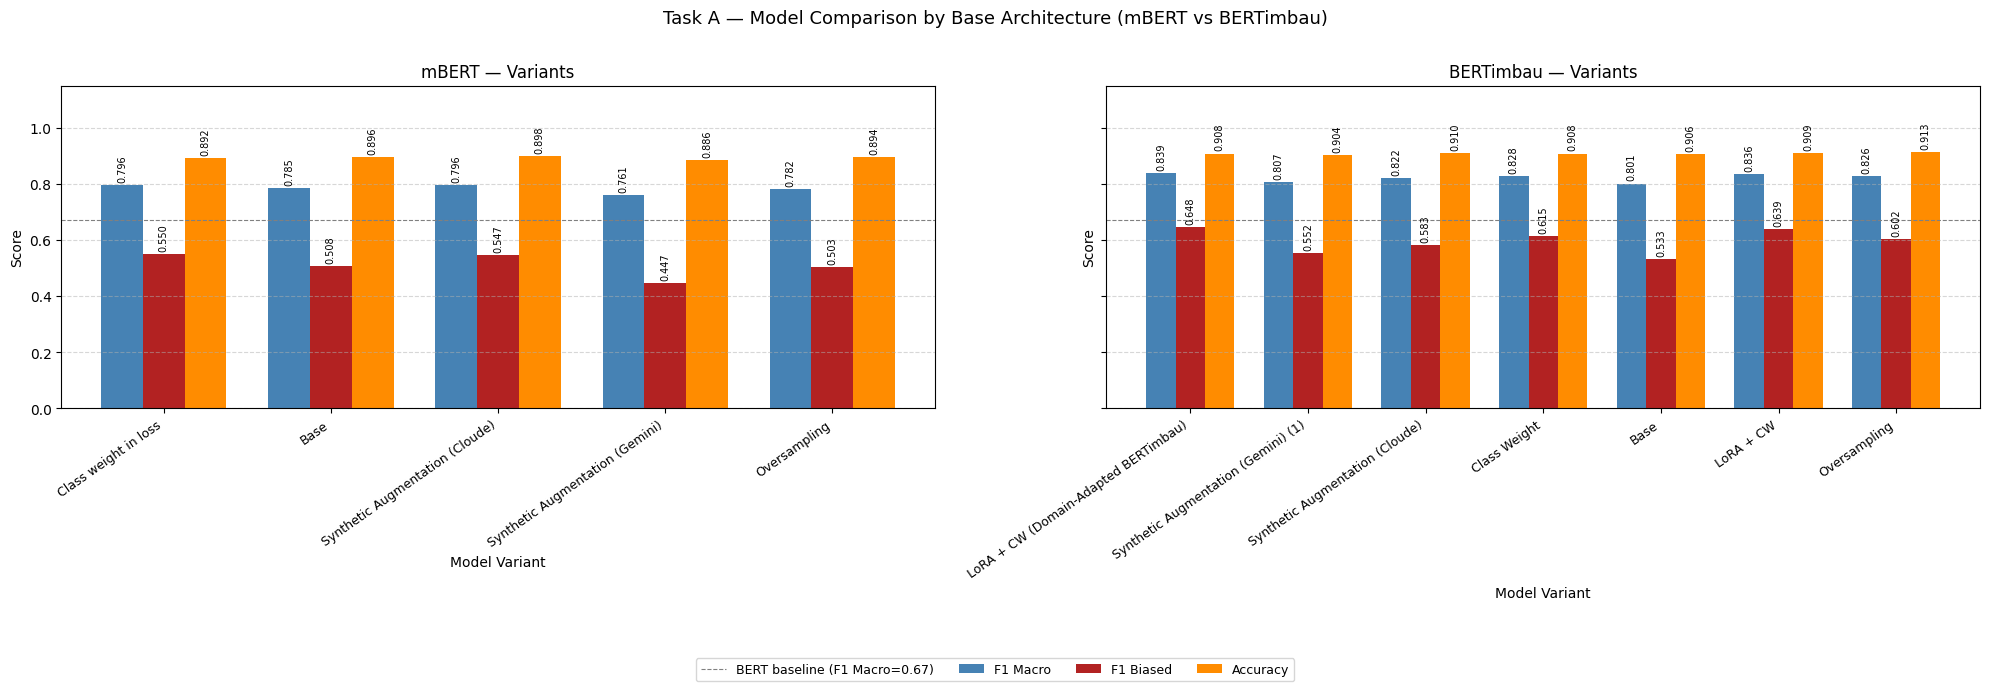

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, accuracy_score


metrics = {}
for name, v in results.items():
    metrics[name] = {
        "f1_macro":  f1_score(v["y_true"], v["y_pred"], average="macro"),
        "f1_biased": f1_score(v["y_true"], v["y_pred"], average=None, labels=[0, 1, 2])[0],
        "accuracy":  accuracy_score(v["y_true"], v["y_pred"]),
    }

groups = {
    "mBERT":     {k: v for k, v in metrics.items() if k.startswith("mBERT")},
    "BERTimbau": {k: v for k, v in metrics.items() if k.startswith("BERTimbau")},
}

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

colors = {"f1_macro": "steelblue", "f1_biased": "firebrick", "accuracy": "darkorange"}
width = 0.25

for ax, (group_name, group_metrics) in zip(axes, groups.items()):
    names  = list(group_metrics.keys())
    labels = [n.replace(f"{group_name} - ", "") for n in names]
    x      = np.arange(len(names))

    for i, (metric, color) in enumerate(colors.items()):
        vals = [group_metrics[n][metric] for n in names]
        bars = ax.bar(x + (i - 1) * width, vals, width, label=metric.replace("_", " ").title(), color=color)
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.3f}",
                ha="center", va="bottom", fontsize=7, rotation=90
            )

    ax.axhline(y=0.67, color="gray", linestyle="--", linewidth=0.8, label="BERT baseline (F1 Macro=0.67)")
    ax.set_title(f"{group_name} — Variants")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_xlabel("Model Variant")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels_leg,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    fontsize=9,
    frameon=True,
)

plt.suptitle("Task A — Model Comparison by Base Architecture (mBERT vs BERTimbau)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("task_a_grouped_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

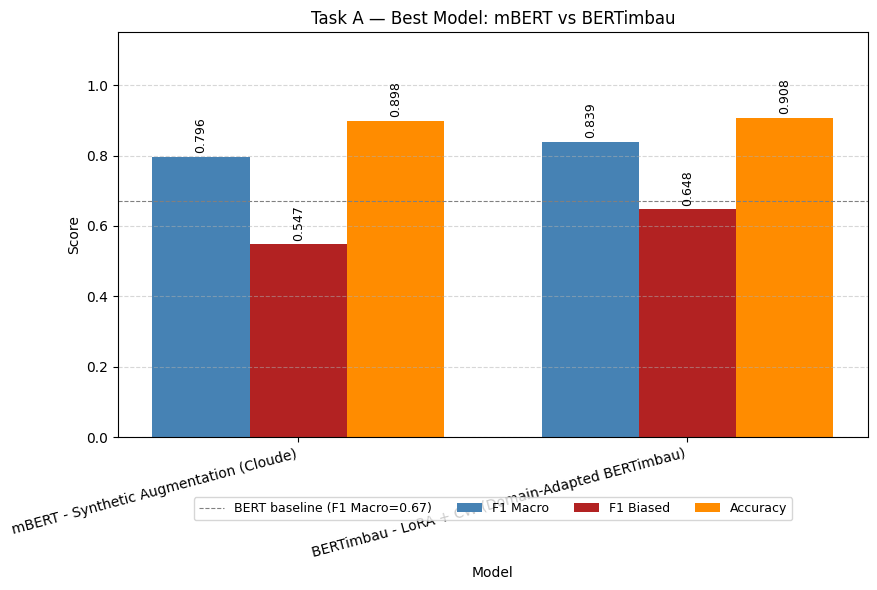

Best mBERT:     mBERT - Synthetic Augmentation (Cloude)  → F1 Macro = 0.796
Best BERTimbau: BERTimbau - LoRA + CW (Domain-Adapted BERTimbau) → F1 Macro = 0.839


In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# ── Rebuild metrics ───────────────────────────────────────────────────────────
metrics = {}
for name, v in results.items():
    metrics[name] = {
        "f1_macro":  f1_score(v["y_true"], v["y_pred"], average="macro"),
        "f1_biased": f1_score(v["y_true"], v["y_pred"], average=None, labels=[0, 1, 2])[0],
        "accuracy":  accuracy_score(v["y_true"], v["y_pred"]),
    }

# ── Best model per architecture (by F1 Macro) ─────────────────────────────────
def best_model(prefix):
    candidates = {k: v for k, v in metrics.items() if k.startswith(prefix)}
    return max(candidates, key=lambda k: candidates[k]["f1_macro"])

best_mbert     = best_model("mBERT")
best_bertimbau = best_model("BERTimbau")

best = {
    best_mbert:     metrics[best_mbert],
    best_bertimbau: metrics[best_bertimbau],
}

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = {"f1_macro": "steelblue", "f1_biased": "firebrick", "accuracy": "darkorange"}
width  = 0.25

names  = list(best.keys())
x      = np.arange(len(names))

fig, ax = plt.subplots(figsize=(9, 6))

for i, (metric, color) in enumerate(colors.items()):
    vals = [best[n][metric] for n in names]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  label=metric.replace("_", " ").title(), color=color)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9, rotation=90
        )

ax.axhline(y=0.67, color="gray", linestyle="--", linewidth=0.8,
           label="BERT baseline (F1 Macro=0.67)")
ax.set_title("Task A — Best Model: mBERT vs BERTimbau")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.grid(axis="y", linestyle="--", alpha=0.5)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=4,
    fontsize=9,
    frameon=True,
)

plt.tight_layout()
plt.savefig("task_a_best_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best mBERT:     {best_mbert}  → F1 Macro = {metrics[best_mbert]['f1_macro']:.3f}")
print(f"Best BERTimbau: {best_bertimbau} → F1 Macro = {metrics[best_bertimbau]['f1_macro']:.3f}")

### mBERT vs BERTimbau — Analysis

#### BERTimbau outperforms mBERT across all variants

Across all evaluated variants, BERTimbau consistently outperformed mBERT, with the best BERTimbau
variant achieving an F1 Macro of **0.839** compared to **0.796** for the best mBERT variant — a
gap of 4.3 percentage points. This result aligns with the broader NLP literature on Brazilian
Portuguese: Souza et al. (2020) show that BERTimbau outperforms mBERT on STS, RTE, and NER
benchmarks, with gains of 2–6 F1 points across tasks (Souza et al., 2020). The advantage is
expected: while mBERT distributes its capacity across 104 languages simultaneously, BERTimbau
was pre-trained exclusively on BrWaC — a large Brazilian Portuguese web corpus — allowing it
to develop richer representations of Portuguese morphology, syntax, and vocabulary. Since the
FactNews dataset consists entirely of Brazilian Portuguese news text, BERTimbau's monolingual
pre-training directly benefits the downstream task.

#### Impact of imbalance-handling strategies

All resampling and class-weighting strategies produced modest but consistent improvements in
F1 Biased relative to the base variant for both architectures, reflecting the difficulty of
learning from a heavily skewed label distribution where the *biased* class represents less than
10% of the dataset. However, the improvements in F1 Macro were relatively small (typically
1–4 points), which is unsurprising: resampling helps the model attend to minority-class
examples, but it does not resolve the fundamental difficulty of detecting subtle linguistic
bias — a challenge rooted in the semantic ambiguity of the task itself, as discussed earlier.
Notably, none of the resampling strategies reliably degraded accuracy, confirming that they
provide a net benefit without significantly harming majority-class performance.

#### Claude vs Gemini synthetic augmentation

Among the synthetic data augmentation strategies, the Claude-generated data consistently
outperformed the Gemini-generated data for both mBERT (F1 Macro 0.796 vs 0.761) and
BERTimbau (F1 Macro 0.828 vs 0.822). While both LLMs were prompted to generate synthetic
biased sentences to balance the training set, this difference suggests that Claude produced
augmentation data that was more linguistically consistent with the FactNews annotation
criteria — in particular, the subtle framing-level bias types (Spin, Word Choice, Mind
Reading) that dominate the dataset. The gap is not dramatic, but it is consistent across
both architectures, lending credibility to the result.

#### Why our base mBERT already exceeds the FactNews baseline

The 67% F1 Macro reported by Vargas et al. (2023) was achieved by fine-tuning
`bert-base-multilingual-cased` on the FactNews dataset — the same architecture used
in our mBERT experiments. Notably, our base mBERT variant (without any resampling)
already achieves **0.785 F1 Macro**, surpassing the original baseline by over 11
percentage points even under comparable conditions. This gap is most likely explained
by differences in training configuration: we trained for 3 epochs with checkpoint
selection based on F1 Macro (`load_best_model_at_end=True`), used a learning rate
of 2e-5 with weight decay, and applied a stratified 80/20 split. Vargas et al. do
not report these details, suggesting their baseline was produced with a simpler
training setup. This confirms that the 67% figure represents a conservative lower
bound, and that even standard fine-tuning with careful configuration substantially
exceeds it.

#### BERTimbau LoRA + CW (Domain-Adapted) — best overall model

The best-performing model overall was **BERTimbau - LoRA + CW (Domain-Adapted BERTimbau)**,
achieving an F1 Macro of **0.839** and an F1 Biased of **0.648** — the highest biased-class
F1 across all evaluated models. This result is the product of three complementary design
choices:

1. **Domain adaptation via continued pre-training**: before fine-tuning on FactNews, BERTimbau
   was subjected to additional Masked Language Modelling on two large Brazilian news corpora —
   Folha UOL News ([Kaggle](https://www.kaggle.com/datasets/marlesson/news-of-the-site-folhauol))
   and Notícias Publicadas no Brasil
   ([Kaggle](https://www.kaggle.com/datasets/diogocaliman/notcias-publicadas-no-brasil)). This
   step updates the model's internal representations to better reflect the lexical and stylistic
   patterns of Brazilian journalism, directly improving its sensitivity to the subtle linguistic
   markers of bias present in FactNews.

2. **LoRA fine-tuning**: rather than updating all 110M parameters, LoRA introduces a small
   number of trainable low-rank adapter matrices while keeping the pre-trained weights frozen.
   This reduces the risk of catastrophic forgetting of the domain-adapted representations
   acquired in the previous step, and provides a strong regularisation effect that is
   particularly valuable given the small size of the FactNews training set.

3. **Class weights in the loss**: the weighted cross-entropy loss compensates for the severe
   class imbalance, allowing the model to achieve the highest F1 Biased score observed — a
   critical metric given that the *biased* class is the primary target of the task.

The combination of these three techniques reflects a principled progression from general
multilingual knowledge (mBERT pre-training) → domain-specific language modelling (Brazilian
news adaptation) → task-specific fine-tuning (LoRA + class weights), and constitutes the
strongest argument for the value of domain adaptation in low-resource, domain-specific NLP
tasks.

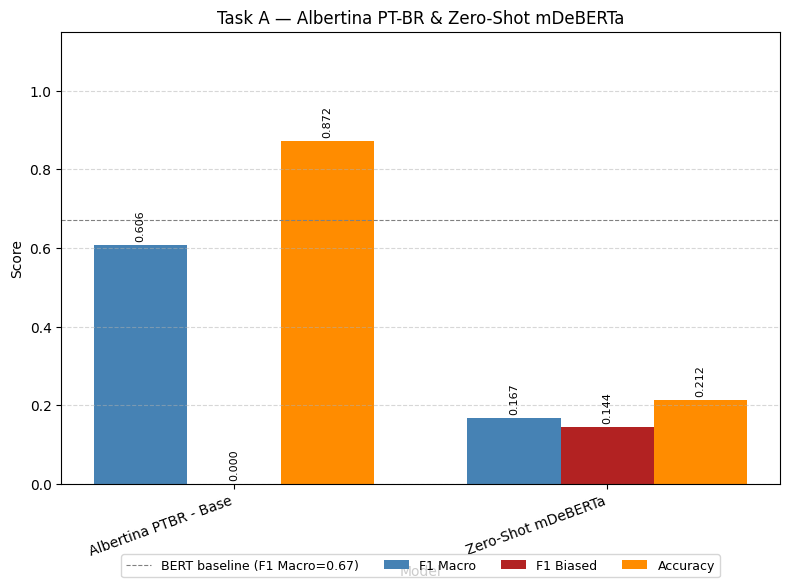

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# ── Rebuild metrics ───────────────────────────────────────────────────────────
metrics = {}
for name, v in results.items():
    metrics[name] = {
        "f1_macro":  f1_score(v["y_true"], v["y_pred"], average="macro"),
        "f1_biased": f1_score(v["y_true"], v["y_pred"], average=None, labels=[0, 1, 2])[0],
        "accuracy":  accuracy_score(v["y_true"], v["y_pred"]),
    }

# ── Filter Albertina and Zero-Shot only ───────────────────────────────────────
other_metrics = {
    k: v for k, v in metrics.items()
    if k.startswith("Albertina") or k.startswith("Zero-Shot")
}

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = {"f1_macro": "steelblue", "f1_biased": "firebrick", "accuracy": "darkorange"}
width  = 0.25

names  = list(other_metrics.keys())
labels = names
x      = np.arange(len(names))

fig, ax = plt.subplots(figsize=(8, 6))

for i, (metric, color) in enumerate(colors.items()):
    vals = [other_metrics[n][metric] for n in names]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  label=metric.replace("_", " ").title(), color=color)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8, rotation=90
        )

ax.axhline(y=0.67, color="gray", linestyle="--", linewidth=0.8,
           label="BERT baseline (F1 Macro=0.67)")
ax.set_title("Task A — Albertina PT-BR & Zero-Shot mDeBERTa")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.grid(axis="y", linestyle="--", alpha=0.5)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=4,
    fontsize=9,
    frameon=True,
)

plt.tight_layout()
plt.savefig("task_a_other_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Albertina PT-BR & Zero-Shot mDeBERTa — Analysis

The chart above reveals a stark contrast between the two models evaluated outside the mBERT/BERTimbau family.

**Albertina PT-BR - Base** achieved an F1 Macro of **0.606**, falling below the BERT baseline of 0.67. While its accuracy reaches **0.872**, this is misleading: the F1 Biased score of **0.000** reveals that the model completely failed to identify any biased sentence, instead defaulting to the majority class (factual). This suggests the model converged to a degenerate solution driven by class imbalance, rather than learning meaningful discriminative features for the minority class.

Several factors may explain Albertina's underperformance relative to mBERT and BERTimbau:

- **No imbalance handling**: unlike mBERT and BERTimbau, which were evaluated with oversampling, class weights, and synthetic augmentation, Albertina was only tested in its base configuration without any resampling strategy. Given that the *biased* class represents less than 10% of the dataset, this alone is likely sufficient to explain the F1 Biased of 0.000.
- **Architecture scale vs. dataset size**: Albertina's 900M parameter RoBERTa-large architecture is substantially over-parameterised for a dataset of ~6,000 sentences. Larger models typically require significantly more data to fine-tune effectively without collapsing to majority-class prediction.
- **Limited exploration**: due to GPU memory and time constraints, only a single base variant was evaluated for Albertina. It is plausible that adding class weights in the loss function — the single most effective technique observed across mBERT and BERTimbau variants — would substantially improve the F1 Biased score.

**Zero-Shot mDeBERTa** performed significantly worse across all metrics (F1 Macro = **0.167**,Accuracy = **0.212**), which is expected and consistent with the literature on zero-shotclassification for fine-grained NLP tasks. Gera et al. (2022) show that NLI-based zero-shotclassifiers, despite their off-the-shelf availability, suffer from instability and performance
degradation when applied to tasks the model was not specifically trained on — a limitation that is particularly pronounced in subjective or pragmatic classification tasks such as media bias detection (Gera et al., EMNLP 2022). The model collapsed almost entirely onto the *quote*
class, reflecting its inability to distinguish subtle pragmatic and framing differences between *biased* and *factual* sentences without task-specific supervision. This result serves as a strong lower-bound baseline: it confirms that media bias detection at the sentence level does
not generalise well from NLI training alone, and that supervised fine-tuning on domain-specific annotated data — such as FactNews — is essential to achieve meaningful performance.

## Error Analysis

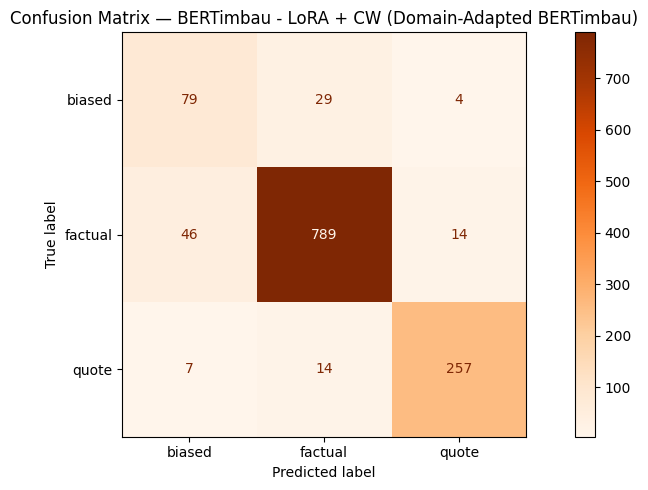

                                              sentences  label_id  y_pred
323   Já Capixaba, acusado de ter recebido R$ 646 mi...         0       1
5382  A transferência do caso para a primeira instân...         0       1
57    Tema foi o mais comentado no Twitter após even...         0       1
4206                                     #NÃOÉBEMASSIM.         0       2
1910  O ouro no revezamento foi especial para Thiago...         0       1


In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Usa o melhor modelo
best_name = "BERTimbau - LoRA + CW (Domain-Adapted BERTimbau)"
y_true = results[best_name]["y_true"]
y_pred = results[best_name]["y_pred"]

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["biased", "factual", "quote"])
disp.plot(cmap="Oranges")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("confusion_matrix_best.png", dpi=150)
plt.show()


test_df["y_pred"] = y_pred
errors = test_df[test_df["label_id"] != test_df["y_pred"]]


biased_errors = errors[errors["label_id"] == 0]
print(biased_errors[["sentences", "label_id", "y_pred"]].head(5))

1st BERTimbau: BERTimbau - LoRA + CW (Domain-Adapted BERTimbau) — F1 Macro: 0.839
2nd BERTimbau: BERTimbau - LoRA + CW — F1 Macro: 0.836


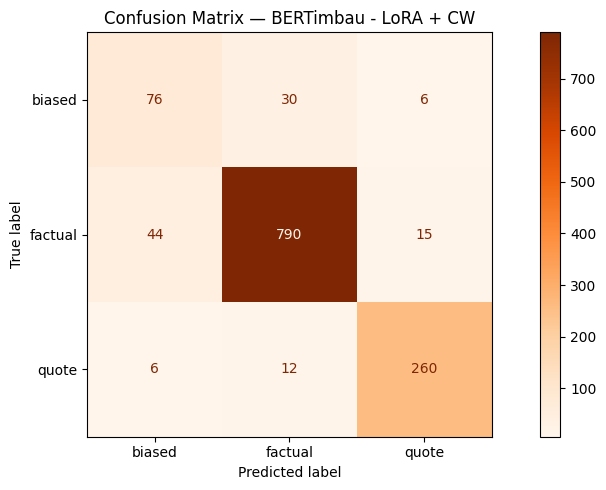


── Biased misclassified ──────────────────────────────────────────────
                                                                                                                                                                               sentences true_label pred_label
                                                                                          Já Capixaba, acusado de ter recebido R$ 646 mil, considera seriamente a hipótese de renunciar.     biased    factual
                                                                                                                     A transferência do caso para a primeira instância traz outro bônus.     biased    factual
                                                                Tema foi o mais comentado no Twitter após evento marcado por memes, ausência de Lula e aliado desconhecido de Bolsonaro.     biased    factual
                                                                                                    

In [33]:
bertimbau_models = {k: v for k, v in metrics.items() if k.startswith("BERTimbau")}
sorted_bertimbau = sorted(bertimbau_models, key=lambda k: bertimbau_models[k]["f1_macro"], reverse=True)

second_best_bertimbau = sorted_bertimbau[1]
y_true = results[second_best_bertimbau]["y_true"]
y_pred = results[second_best_bertimbau]["y_pred"]

print(f"1st BERTimbau: {sorted_bertimbau[0]} — F1 Macro: {metrics[sorted_bertimbau[0]]['f1_macro']:.3f}")
print(f"2nd BERTimbau: {second_best_bertimbau} — F1 Macro: {metrics[second_best_bertimbau]['f1_macro']:.3f}")


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["biased", "factual", "quote"])
disp.plot(cmap="Oranges")
plt.title(f"Confusion Matrix — {second_best_bertimbau}")
plt.tight_layout()
plt.savefig("confusion_matrix_2nd_bertimbau.png", dpi=150)
plt.show()


test_df["y_pred"] = y_pred
errors = test_df[test_df["label_id"] != test_df["y_pred"]].copy()
errors["true_label"] = errors["label_id"].map(TARGET_NAMES_MAP)
errors["pred_label"] = errors["y_pred"].map(TARGET_NAMES_MAP)

print("\n── Biased misclassified ──────────────────────────────────────────────")
biased_errors = errors[errors["label_id"] == 0][["sentences", "true_label", "pred_label"]]
print(biased_errors.head(5).to_string(index=False))

print("\n── Factual misclassified as biased ───────────────────────────────────")
fp_errors = errors[(errors["label_id"] == 1) & (errors["y_pred"] == 0)][["sentences", "true_label", "pred_label"]]
print(fp_errors.head(5).to_string(index=False))

print("\n── Error distribution by true class ─────────────────────────────────")
print(errors["true_label"].value_counts())

Best mBERT model: mBERT - Synthetic Augmentation (Cloude)
F1 Macro: 0.796


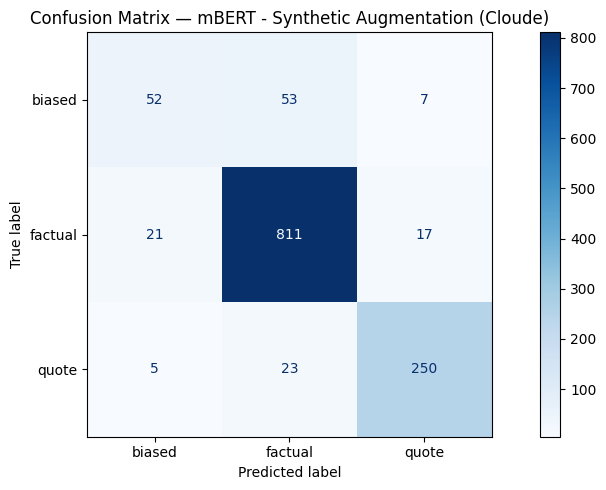


── Biased misclassified ──────────────────────────────────────────────
                                                                                                                                                                                              sentences true_label pred_label
Em um dos massacres mais mortais da história da Tailândia, um ex-policial matou 37 pessoas, incluindo 24 crianças de dois a cinco anos -a maioria a facadas- ao invadir uma creche no nordeste do país.     biased    factual
                                                                                                         Já Capixaba, acusado de ter recebido R$ 646 mil, considera seriamente a hipótese de renunciar.     biased    factual
                                                                                                                                    A transferência do caso para a primeira instância traz outro bônus.     biased    factual
                                        

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_mbert = max(
    {k: v for k, v in metrics.items() if k.startswith("mBERT")},
    key=lambda k: metrics[k]["f1_macro"]
)

y_true = results[best_mbert]["y_true"]
y_pred = results[best_mbert]["y_pred"]

print(f"Best mBERT model: {best_mbert}")
print(f"F1 Macro: {metrics[best_mbert]['f1_macro']:.3f}")


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["biased", "factual", "quote"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_mbert}")
plt.tight_layout()
plt.savefig("confusion_matrix_best_mbert.png", dpi=150)
plt.show()

test_df["y_pred"] = y_pred

TARGET_NAMES_MAP = {0: "biased", 1: "factual", 2: "quote"}
errors = test_df[test_df["label_id"] != test_df["y_pred"]].copy()
errors["true_label"] = errors["label_id"].map(TARGET_NAMES_MAP)
errors["pred_label"] = errors["y_pred"].map(TARGET_NAMES_MAP)

print("\n── Biased misclassified ──────────────────────────────────────────────")
biased_errors = errors[errors["label_id"] == 0][["sentences", "true_label", "pred_label"]]
print(biased_errors.head(5).to_string(index=False))

print("\n── Factual misclassified as biased ───────────────────────────────────")
fp_errors = errors[(errors["label_id"] == 1) & (errors["y_pred"] == 0)][["sentences", "true_label", "pred_label"]]
print(fp_errors.head(5).to_string(index=False))

print("\n── Error distribution by true class ─────────────────────────────────")
print(errors["true_label"].value_counts())


### General Pattern Across All Models

The confusion matrices reveal a consistent pattern across all three models: **the *biased* class is the hardest to classify correctly**. In every model, the majority of errors occur in the *biased* row, where a significant fraction is misclassified as *factual*. This is linguistically expected — subtly biased sentences share surface structure with factual ones, making the *biased/factual* boundary inherently ambiguous. By contrast, *factual* and *quote* are well separated from each other, with very few cross-errors between them.

---

### mBERT — Synthetic Augmentation (Claude)

This is the best-performing mBERT variant, yet it still shows the **weakest performance on the *biased* class**
across all three models: only 52 out of 112 instances are correctly classified (~46%), while 53 are
misclassified as *factual* — more errors than correct predictions. This limitation is likely inherent to
mBERT's multilingual pretraining, which, despite covering Portuguese, was not optimised for the linguistic
nuances of Portuguese news bias. The *biased/factual* boundary requires a deep understanding of subtle
framing cues that a language-specific model handles more effectively. The model compensates with strong
performance on *factual* (811/849) and *quote* (250/278), where surface-level patterns are more distinctive.

---

### BERTimbau — LoRA + CW

This model achieves a clear improvement on *biased*: 76 correct out of 112 (~68%), with only 30
misclassified as *factual*. This result highlights the combined contribution of both techniques —
Class Weighting alone yielded weaker results, suggesting that LoRA's parameter-efficient fine-tuning
plays a critical role in reshaping the model's decision boundary for the minority class. By selectively
updating low-rank adapter weights, LoRA allows the model to adapt more precisely to the *biased/factual*
distinction without overfitting to the majority class. The expected CW trade-off is still visible,
44 *factual* instances are predicted as *biased*, but the gain in *biased* recall more than compensates,
as reflected in the F1 Macro score.

---

### BERTimbau — LoRA + CW (Domain-Adapted)

This is the **best-performing model on the *biased* class**: 79 correct (~71%), with only 29 misclassified as *factual* and just 4 as *quote* — the lowest value in that cell across all models. Domain adaptation further sharpened the *biased/factual* boundary. The cost in *factual* (46 predicted as *biased*) is marginally higher than the non-adapted variant, but the gain in *biased* recall justifies the trade-off.

---

### Biased Class Recall Summary

| Model | Correct (Biased) | → Factual | → Quote | Biased Recall |
|---|---|---|---|---|
| mBERT — Synthetic Augmentation | 52 | 53 | 7 | ~46% |
| BERTimbau — LoRA + CW | 76 | 30 | 6 | ~68% |
| BERTimbau — LoRA + CW (Domain-Adapted) | **79** | **29** | **4** | **~71%** |

The progression from 46% → 68% → 71% in *biased* recall directly explains the F1 Macro improvements across models, and validates the selection of the Domain-Adapted BERTimbau as the final model.

### The Linguistic Complexity of *Biased* Classification

A key insight from the original FactNews paper (Vargas et al., 2023) helps explain the error patterns
observed across all models. The *biased* class encompasses 12 distinct types of media bias — including
Spin, Word Choice, Subjective Adjectives, and Mind Reading — annotated manually by two experts
(a linguist and a computer scientist) achieving a Cohen's kappa of 82%.

| # | Bias Type | Description |
|---|---|---|
| 1 | **Spin** | Interpretation that goes beyond the facts reported |
| 2 | **Word Choice** | Use of emotionally charged or loaded vocabulary |
| 3 | **Subjective Adjectives** | Adjectives that reflect opinion rather than fact |
| 4 | **Mind Reading** | Attribution of thoughts or intentions without evidence |
| 5 | **Generalization** | Broad claims drawn from insufficient evidence |
| 6 | **Omission** | Selective exclusion of relevant information |
| 7 | **Placement** | Strategic positioning of information to influence perception |
| 8 | **Story Selection** | Choice of which stories to cover or ignore |
| 9 | **Source Selection** | Choice of which sources to quote or omit |
| 10 | **Labeling** | Use of ideologically charged labels for people or groups |
| 11 | **Framing** | Presenting facts within a particular ideological context |
| 12 | **Sensationalism** | Exaggeration or dramatization of events |

The vast majority of these bias types are subtle and operate at the phrasal level, producing no
distinctive vocabulary that a model can easily latch onto. A sentence such as *"Bolsonaro followed
the campaign script in his speech"* is labelled *biased* due to Spin (*"followed the script"*), yet
the word *"script"* appears naturally in factual journalism. This difficulty is further compounded
by the sentence-level granularity of the task: unlike document-level bias detection, where cumulative
patterns of framing, source selection, and omission become evident across a full article, classifying
individual sentences strips away the broader context that is often essential to identify bias. A
sentence that reads as neutral in isolation may only reveal its biased framing when read alongside
the surrounding paragraph. This explains why all models (regardless of architecture or training
strategy) consistently struggle with the *biased/factual* boundary: the signal is not lexical, but
pragmatic and contextual, requiring a deeper understanding of framing that even language-specific
models only partially capture.

## References

Gera, A., Halfon, A., Shnarch, E., Perlitz, Y., Ein-Dor, L., & Slonim, N. (2022).
Zero-Shot Text Classification with Self-Training. In Proceedings of the 2022 Conference
on Empirical Methods in Natural Language Processing (EMNLP), pages 1107–1119.
Association for Computational Linguistics.